# Used Car Data Cleaning Pipeline

## Overview

Real-world datasets often contain missing values, inconsistent formatting, and outliers that reduce the quality of predictive models.

This notebook demonstrates a repeatable data cleaning workflow using a used vehicle sales dataset. The analysis includes data inspection, missing value handling, outlier removal, visualization, and export of a cleaned dataset suitable for regression modeling.

In [16]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [17]:
project_dir = Path.cwd()

data_path = project_dir / "used_car_sales.csv"

figures_dir = project_dir / "figures"

figures_dir.mkdir(exist_ok=True)

print(project_dir)
print(data_path)
print(figures_dir)

/Users/briansentz/Desktop/Python Projects/Data Science Portfolio/Practical Linear Regression
/Users/briansentz/Desktop/Python Projects/Data Science Portfolio/Practical Linear Regression/used_car_sales.csv
/Users/briansentz/Desktop/Python Projects/Data Science Portfolio/Practical Linear Regression/figures


In [22]:
cars = pd.read_csv(data_path)

# Standardize column names
cars.columns = (
    cars.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)

# Match the naming used throughout the notebook
cars.rename(
    columns={
        "enginev": "engine_volume"
    },
    inplace=True
)

print(cars.columns.tolist())

cars.head()

['brand', 'price', 'body', 'mileage', 'engine_volume', 'engine_type', 'registration', 'year', 'model']


,brand,price,body,mileage,engine_volume,engine_type,registration,year,model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [23]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          4345 non-null   object 
 1   price          4173 non-null   float64
 2   body           4345 non-null   object 
 3   mileage        4345 non-null   int64  
 4   engine_volume  4195 non-null   float64
 5   engine_type    4345 non-null   object 
 6   registration   4345 non-null   object 
 7   year           4345 non-null   int64  
 8   model          4345 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 305.6+ KB


In [24]:
cars.describe()

,price,mileage,engine_volume,year
count,4173.000000,4345.000000,4195.000000,4345.000000
mean,19418.746935,161.237284,2.790734,2006.550058
std,25584.242620,105.705797,5.066437,6.719097
min,600.000000,0.000000,0.600000,1969.000000
25%,6999.000000,86.000000,1.800000,2003.000000
50%,11500.000000,155.000000,2.200000,2008.000000
75%,21700.000000,230.000000,3.000000,2012.000000
max,300000.000000,980.000000,99.990000,2016.000000


In [25]:
cars.isna().sum()

brand              0
price            172
body               0
mileage            0
engine_volume    150
engine_type        0
registration       0
year               0
model              0
dtype: int64

## Initial Data Exploration

Before cleaning the dataset, we inspect the distributions of several numerical variables to identify missing values, skewness, and potential outliers that could negatively affect downstream regression models.

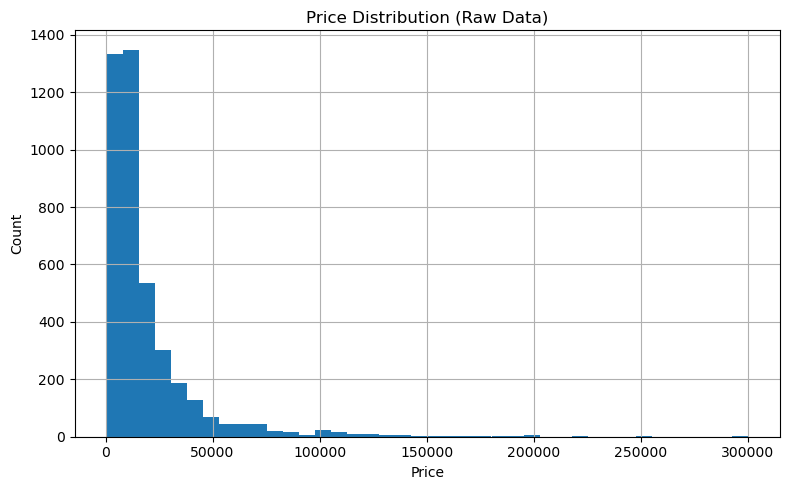

In [26]:
plt.figure(figsize=(8,5))

cars["price"].hist(bins=40)

plt.title("Price Distribution (Raw Data)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    figures_dir / "before_price_distribution.png",
    dpi=300
)

plt.show()

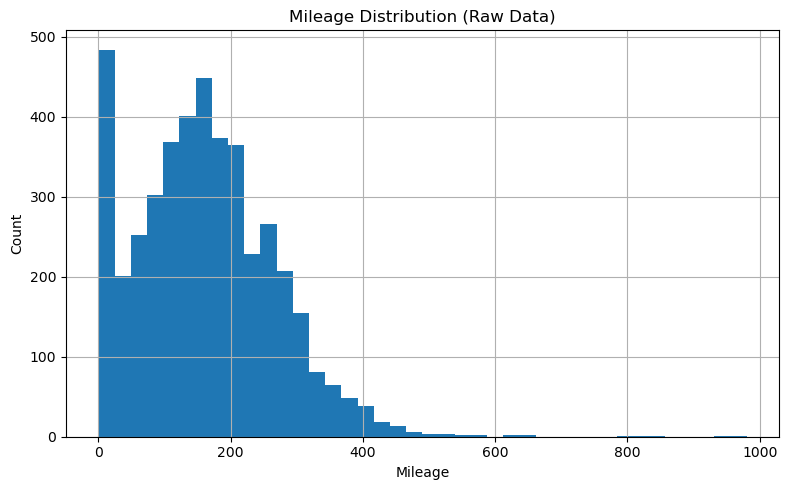

In [27]:
plt.figure(figsize=(8,5))

cars["mileage"].hist(bins=40)

plt.title("Mileage Distribution (Raw Data)")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    figures_dir / "before_mileage_distribution.png",
    dpi=300
)

plt.show()

In [28]:
cars_clean = cars.dropna().copy()

print(f"Original Rows: {len(cars):,}")
print(f"Rows After Cleaning: {len(cars_clean):,}")
print(f"Rows Removed: {len(cars)-len(cars_clean):,}")

Original Rows: 4,345
Rows After Cleaning: 4,025
Rows Removed: 320


In [29]:
price_99 = cars_clean["price"].quantile(.99)

cars_clean = cars_clean[
    cars_clean["price"] <= price_99
]

mileage_99 = cars_clean["mileage"].quantile(.99)

cars_clean = cars_clean[
    cars_clean["mileage"] <= mileage_99
]

cars_clean = cars_clean[
    (cars_clean["engine_volume"] >= .6)
    &
    (cars_clean["engine_volume"] <= 6.5)
]

cars_clean.head()

,brand,price,body,mileage,engine_volume,engine_type,registration,year,model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


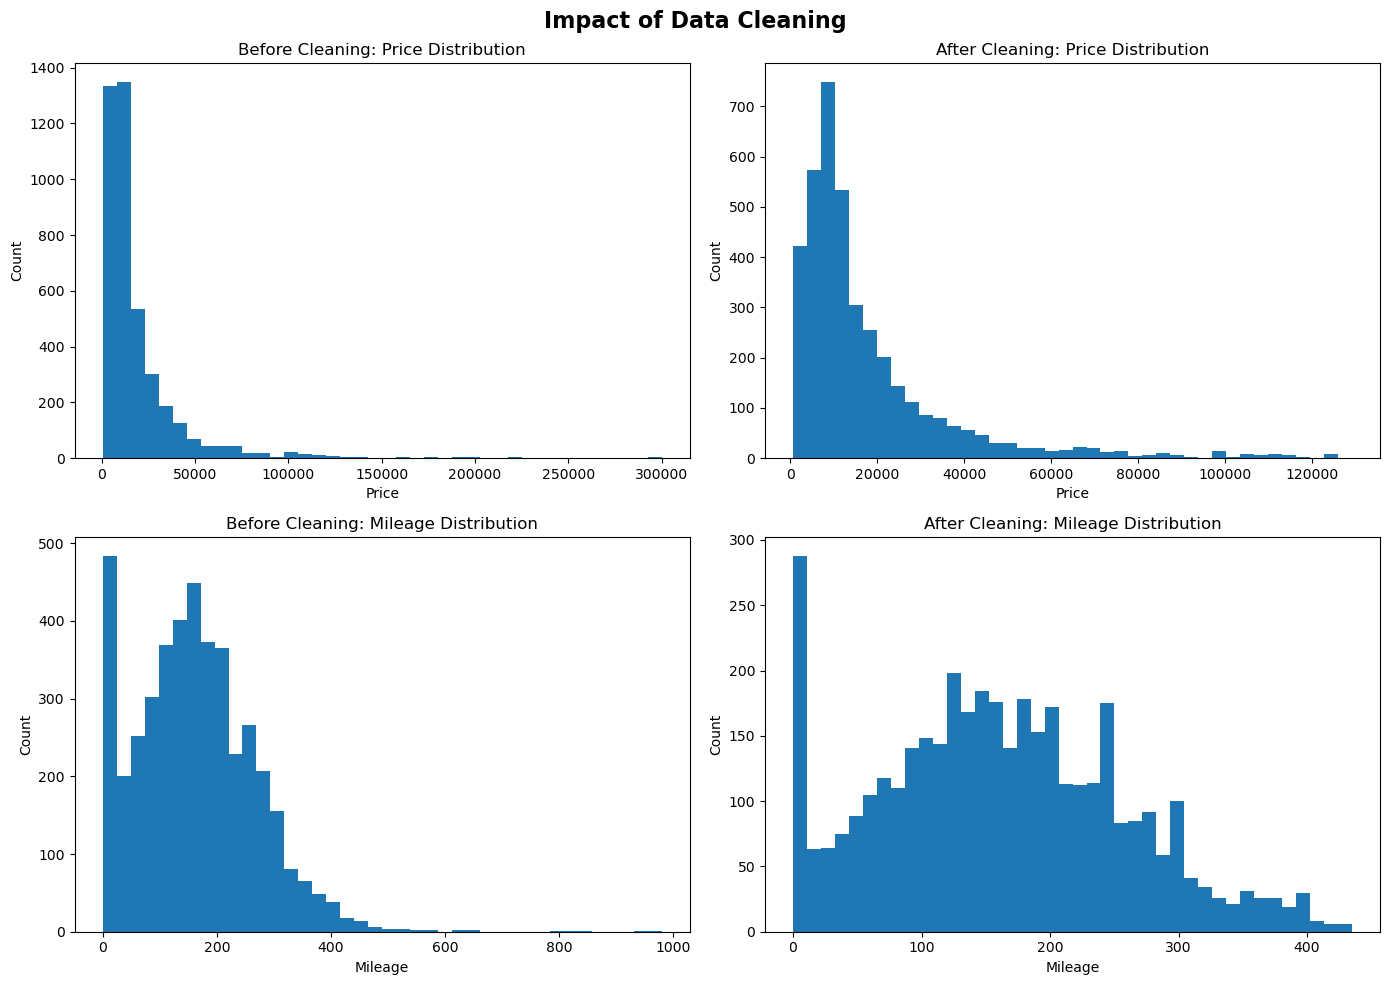

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------
# Price Distribution
# -----------------------------

axes[0, 0].hist(cars["price"], bins=40)

axes[0, 0].set_title("Before Cleaning: Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(cars_clean["price"], bins=40)

axes[0, 1].set_title("After Cleaning: Price Distribution")
axes[0, 1].set_xlabel("Price")
axes[0, 1].set_ylabel("Count")

# -----------------------------
# Mileage Distribution
# -----------------------------

axes[1, 0].hist(cars["mileage"], bins=40)

axes[1, 0].set_title("Before Cleaning: Mileage Distribution")
axes[1, 0].set_xlabel("Mileage")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(cars_clean["mileage"], bins=40)

axes[1, 1].set_title("After Cleaning: Mileage Distribution")
axes[1, 1].set_xlabel("Mileage")
axes[1, 1].set_ylabel("Count")

plt.suptitle(
    "Impact of Data Cleaning",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "before_after_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
cars_clean.to_csv(
    "used_car_sales_cleaned.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


## Conclusions

The data cleaning pipeline successfully prepared the dataset for regression modeling by:

- Removing missing values
- Filtering unrealistic engine sizes
- Removing extreme price and mileage outliers
- Standardizing column names

These preprocessing steps reduced noise and produced cleaner distributions suitable for predictive analytics.